In [1]:
##### Creates maps of final predictors used in RF model

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# import predictor data
capital_predictors = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_absolute.csv")
labor_predictors = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_absolute.csv")

# import thinned regions
capital_predictors_thin = pd.read_csv(f"{cd}/Data/Clean/Training_data/capital_relative_final_thinned.csv")
labor_predictors_thin = pd.read_csv(f"{cd}/Data/Clean/Training_data/labor_relative_final_thinned.csv")

# Import sub-national boudnaries
sub_geo_capital = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_geo_labor = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# Import country boundaries
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/map_predictors"

In [3]:
### Data prep

# align rasters to capital grid
target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

sub_geo_capital = sub_geo_capital.to_crs(target_crs)
sub_geo_labor = sub_geo_labor.to_crs(target_crs)

country_boundaries = country_boundaries.to_crs(target_crs)

In [4]:
##### Clean predictor data 

# filter down to only regions used after data thinning 
capital_predictors = capital_predictors.merge(capital_predictors_thin['PROJ_ID'], on='PROJ_ID', how='right')
labor_predictors = labor_predictors.merge(labor_predictors_thin['PROJ_ID'], on='PROJ_ID', how='right')

# filter to final predictors

capital_cols = ['average_travel_time_port',
       'crop_intensity',
       'USD_production_per_HA',
       'tonnes_production_per_HA',
       'pop_density_people_per_km2',
       'cattle_density_per_km2',
       'sheep_density_per_km2',
       'livestock_density_LU_per_km2',
       'cereals_share_production_tonnes',
       'fruits_share_production_tonnes',
       'roots_tubers_share_production_tonnes',
       'vegetables_share_production_tonnes',
       'ruminants_share_production_tonnes',
       'share_large_field',
       'share_with_nightlights']

labor_cols = ['average_travel_time_port',
       'crop_intensity',
       'pop_density_people_per_km2',
       'cattle_density_per_km2',
       'livestock_density_LU_per_km2',
       'fruits_share_production_tonnes',
       'roots_tubers_share_production_tonnes',
       'rest_of_crops_share_production_tonnes',
       'sugar_crops_share_production_tonnes',
       'ruminants_share_production_tonnes',
       'pct_GDP_ag', 'share_large_field',
       'pct_cropland_irrigated']

capital_predictors= capital_predictors[capital_cols + ['PROJ_ID']]
labor_predictors= labor_predictors[labor_cols + ['PROJ_ID']]

# join with GEO_ID
capital_predictors_geo = sub_geo_capital.merge(capital_predictors, on='PROJ_ID', how='left')
labor_predictors_geo = sub_geo_labor.merge(labor_predictors, on='PROJ_ID', how='left')


In [5]:
##### Classify each variable into percentiles of its distribution
def add_percentiles(df, cols):
    """Add a '<col>_pctile' column (0-100) based on each variable's
    rank across all rows with non-missing data."""
    df = df.copy()
    for col in cols:
        df[f"{col}_pctile"] = df[col].rank(pct=True, na_option='keep') * 100
    return df

capital_predictors_geo = add_percentiles(capital_predictors_geo, capital_cols)
labor_predictors_geo = add_percentiles(labor_predictors_geo, labor_cols)

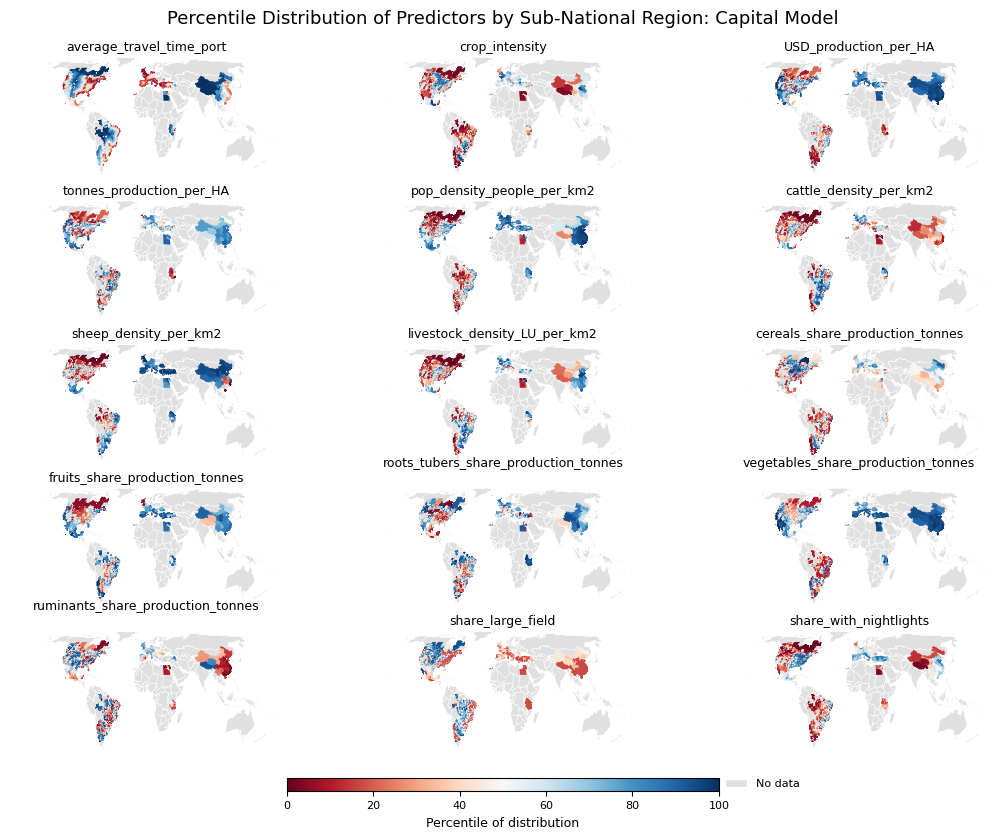

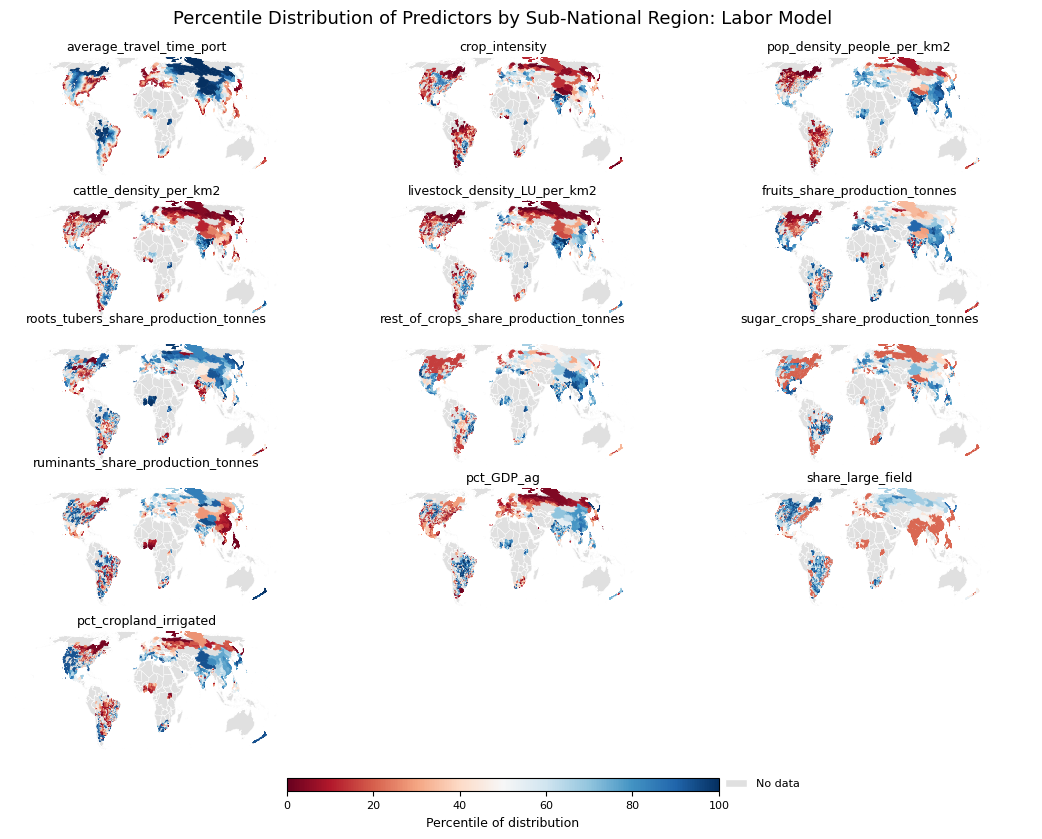

In [6]:
##### Plot grid of choropleths, one map per variable, colored by percentile
def plot_percentile_grid(gdf, cols, country_gdf, suptitle, savepath, ncols=3):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    cmap = plt.cm.RdBu  # red (low percentile) -> blue (high percentile)
    norm = plt.Normalize(vmin=0, vmax=100)
    nodata_color = "0.88"  # very light grey

    # tight, shared extent based on actual data bounds (avoids per-panel padding)
    minx, miny, maxx, maxy = country_gdf.total_bounds
    x_pad = (maxx - minx) * 0.02
    y_pad = (maxy - miny) * 0.02
    minx, maxx = minx - x_pad, maxx + x_pad
    miny, maxy = miny - y_pad, maxy + y_pad
    data_aspect = (maxx - minx) / (maxy - miny)  # width:height ratio

    # size each panel to match the data's actual aspect ratio (wide, short)
    # rather than forcing a square, which was the source of the dead space
    panel_width = 3.6
    panel_height = panel_width / data_aspect

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(panel_width * ncols, panel_height * nrows),
                              squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        pct_col = f"{col}_pctile"

        # country boundaries underneath, light grey fill = "no data" base layer
        country_gdf.plot(ax=ax, color=nodata_color, edgecolor="white",
                          linewidth=0.3, zorder=1)

        # only plot sub-regions that have data for this variable
        sub = gdf[gdf[pct_col].notna()]
        if len(sub) > 0:
            edge_colors = [cmap(norm(v)) for v in sub[pct_col]]
            sub.plot(ax=ax, column=pct_col, cmap=cmap, norm=norm,
                      edgecolor=edge_colors, linewidth=0.3, zorder=2)

        ax.set_title(col, fontsize=9, pad=3)
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        ax.set_aspect("equal")
        ax.axis("off")

    # turn off any unused grid cells
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # tight spacing since panels are already sized to their content
    fig.subplots_adjust(left=0.01, right=0.99, top=0.93, bottom=0.08,
                         wspace=0.03, hspace=0.15)

    # single shared 0-100 colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar_ax = fig.add_axes([0.3, 0.035, 0.4, 0.015])  # [left, bottom, width, height]
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("Percentile of distribution", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    # "no data" legend entry, next to the colorbar
    nodata_patch = mpatches.Patch(facecolor=nodata_color, edgecolor="white",
                                   label="No data")
    fig.legend(handles=[nodata_patch], loc="lower center",
               bbox_to_anchor=(0.74, 0.025), frameon=False, fontsize=8)

    fig.suptitle(suptitle, fontsize=13, y=0.985)
    fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

os.makedirs(fd, exist_ok=True)

plot_percentile_grid(capital_predictors_geo, capital_cols, country_boundaries,
                      "Percentile Distribution of Predictors by Sub-National Region: Capital Model",
                      f"{fd}/capital_predictors_percentile_grid.png", ncols=3)

plot_percentile_grid(labor_predictors_geo, labor_cols, country_boundaries,
                      "Percentile Distribution of Predictors by Sub-National Region: Labor Model",
                      f"{fd}/labor_predictors_percentile_grid.png", ncols=3)